In [44]:
import numpy as np
import optuna
import pandas as pd
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import f1_score, accuracy_score
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
data = pd.read_csv('../assets/breast_cancer.csv')

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
print('row: ', data.shape[0])
print('column: ', data.shape[1])

row:  569
column:  33


In [5]:
target_cols = 'diagnosis'
X = data.loc[:, data.columns != target_cols]
y = data[target_cols]

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# CatBoost

In [7]:
from catboost import CatBoostClassifier

model =  CatBoostClassifier(
	iterations=15, 
	verbose=5
)

model.fit(
	X_train, y_train,
	eval_set=(X_validation, y_validation)
)

Learning rate set to 0.150973
0:	learn: 0.4900468	test: 0.4965018	best: 0.4965018 (0)	total: 148ms	remaining: 2.07s
5:	learn: 0.1664002	test: 0.1693576	best: 0.1693576 (5)	total: 166ms	remaining: 250ms
10:	learn: 0.0803753	test: 0.0956315	best: 0.0956315 (10)	total: 178ms	remaining: 64.8ms
14:	learn: 0.0553971	test: 0.0842840	best: 0.0841154 (13)	total: 186ms	remaining: 0us

bestTest = 0.08411535791
bestIteration = 13

Shrink model to first 14 iterations.


In [8]:
baseModel = CatBoostClassifier(
	learning_rate=0.1, 
	random_seed=63, 
	iterations=50,
	depth=3
)

baseModel.fit(
	X_train, y_train, 
	verbose=False, 
	plot=True, 
	eval_set=(X_validation, y_validation)
)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

# Compare Models

## Learning rate

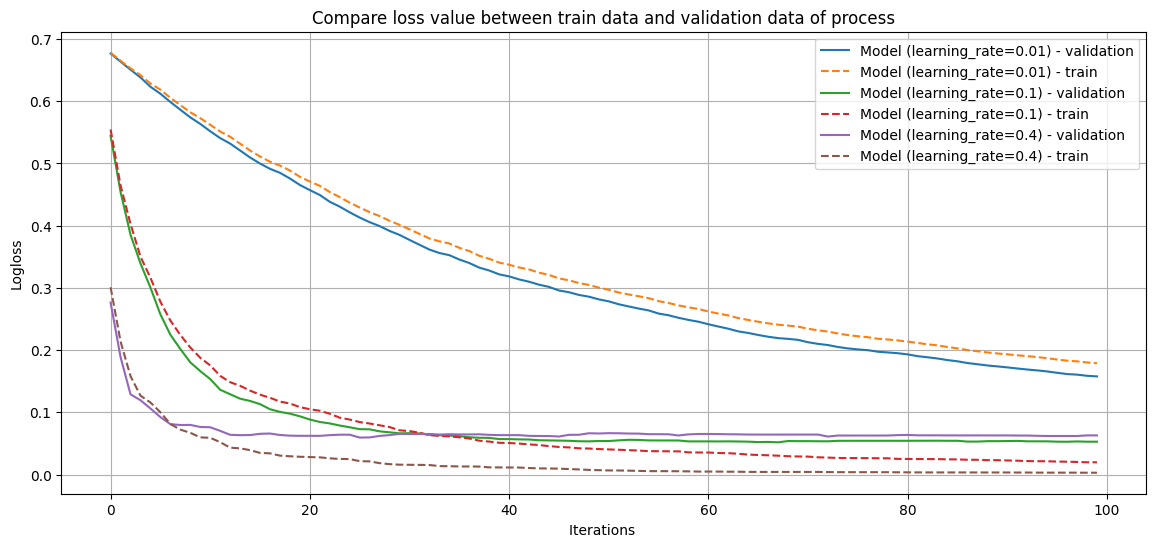

In [ ]:
hyperparams_list = [
	{
		'depth': 3, 
		'learning_rate': 0.01, 
		'iterations': 100, 
		'random_seed': 0, 
		'name': 'Model (learning_rate=0.01)'
    }, 
	{
		'depth': 3, 
		'learning_rate': 0.1, 
		'iterations': 100, 
		'random_seed': 0,
		'name': 'Model (learning_rate=0.1)',	
    },
	{
		'depth': 3, 
		'learning_rate': 0.4, 
		'iterations': 100, 
		'random_seed': 0,
		'name': 'Model (learning_rate=0.4)'	
    }
]

plt.figure(figsize=(14, 6))

f1_score_lr = []
accuracy_score_lr = []

for param in hyperparams_list:
	model_name = param.pop('name')

	model = CatBoostClassifier(
		**param, 
		loss_function='Logloss', 
		eval_metric='Accuracy', 
		use_best_model=False, 
		verbose=0
	)

	model.fit(X_train, y_train, eval_set=(X_validation, y_validation))

	y_pred_model = model.predict(X_test)
	f1_score_lr.append({'value': f1_score(y_test, y_pred_model, pos_label='B'), 'lr': param['learning_rate']})
	accuracy_score_lr.append({'value': accuracy_score(y_test, y_pred_model), 'lr': param['learning_rate']})

	result = model.get_evals_result()
	train_loss = result['learn']['Logloss']
	val_loss = result['validation']['Logloss']
	epochs = range(len(train_loss))

	plt.plot(epochs, val_loss, label=f'{model_name} - validation', linestyle='-')
	plt.plot(epochs, train_loss, label=f'{model_name} - train', linestyle='--')


plt.title('Compare loss value between train data and validation data of process')
plt.xlabel('Iterations ')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
for item in f1_score_lr: 
	print(f'Accuracy value with learning rate = {item}')

for item in accuracy_score_lr:
	print(f'F1-score value with learning rare = {item}')

Accuracy value with learning rate = {'value': 0.9615384615384616, 'lr': 0.01}
Accuracy value with learning rate = {'value': 0.987012987012987, 'lr': 0.1}
Accuracy value with learning rate = {'value': 0.9673202614379085, 'lr': 0.4}
F1-score value with learning rare = {'value': 0.9473684210526315, 'lr': 0.01}
F1-score value with learning rare = {'value': 0.9824561403508771, 'lr': 0.1}
F1-score value with learning rare = {'value': 0.956140350877193, 'lr': 0.4}


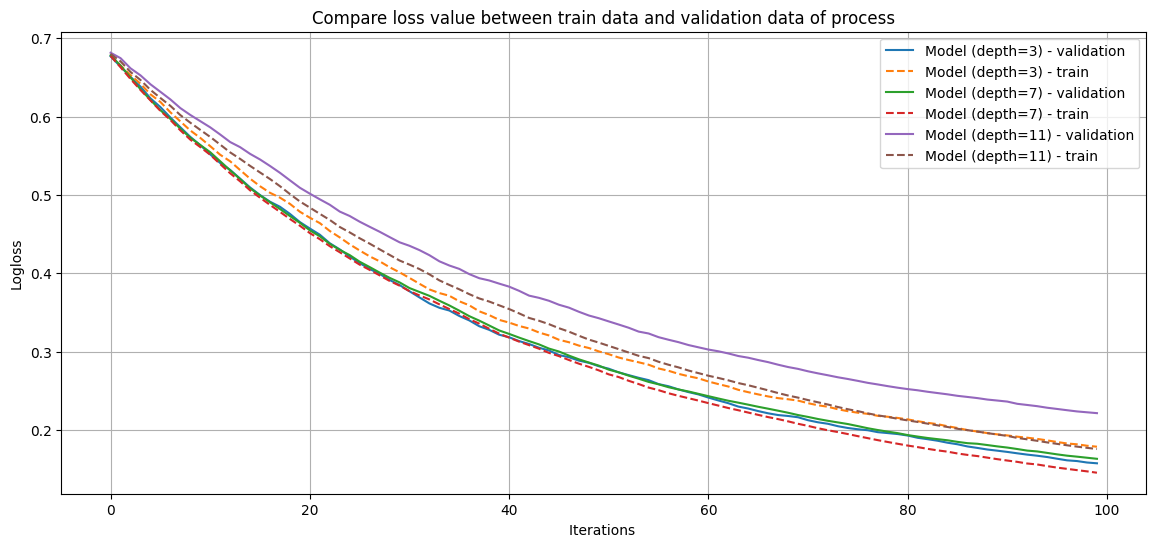

In [39]:
hyperparams_list = [
	{
		'depth': 3, 
		'learning_rate': 0.01, 
		'iterations': 100, 
		'random_seed': 0, 
		'name': 'Model (depth=3)'
    }, 
	{
		'depth': 7, 
		'learning_rate': 0.01, 
		'iterations': 100, 
		'random_seed': 0,
		'name': 'Model (depth=7)',	
    },
	{
		'depth': 11, 
		'learning_rate': 0.01, 
		'iterations': 100, 
		'random_seed': 0,
		'name': 'Model (depth=11)'	
    }
]

plt.figure(figsize=(14, 6))

f1_score_depth = []
accuracy_score_depth = []

for param in hyperparams_list:
	model_name = param.pop('name')

	model = CatBoostClassifier(
		**param, 
		loss_function='Logloss', 
		eval_metric='Accuracy', 
		use_best_model=False, 
		verbose=0
	)

	model.fit(X_train, y_train, eval_set=(X_validation, y_validation))

	y_pred_model = model.predict(X_test)
	f1_score_depth.append({'value': f1_score(y_test, y_pred_model, pos_label='B'), 'depth': param['depth']})
	accuracy_score_depth.append({'value': accuracy_score(y_test, y_pred_model), 'depth': param['depth']})


	result = model.get_evals_result()
	train_loss = result['learn']['Logloss']
	val_loss = result['validation']['Logloss']
	epochs = range(len(train_loss))

	plt.plot(epochs, val_loss, label=f'{model_name} - validation', linestyle='-')
	plt.plot(epochs, train_loss, label=f'{model_name} - train', linestyle='--')


plt.title('Compare loss value between train data and validation data of process')
plt.xlabel('Iterations ')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
for item in f1_score_depth: 
	print(f'Accuracy value = {item}')

for item in accuracy_score_depth:
	print(f'F1-score value = {item}')

Accuracy value = {'value': 0.9615384615384616, 'depth': 3}
Accuracy value = {'value': 0.9681528662420382, 'depth': 7}
Accuracy value = {'value': 0.9806451612903225, 'depth': 11}
F1-score value = {'value': 0.9473684210526315, 'depth': 3}
F1-score value = {'value': 0.956140350877193, 'depth': 7}
F1-score value = {'value': 0.9736842105263158, 'depth': 11}


## Best model

In [45]:
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 500),
        "depth": trial.suggest_int("depth", 1, 16),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature", 0.1, 10.0, log=True
        ),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "grow_policy": trial.suggest_categorical(
            "grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]
        ),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "rsm": trial.suggest_float("rsm", 0.1, 1.0),
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "verbose": 0,
    }

    model = CatBoostClassifier(**params)

    scores = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring="f1_weighted",
        cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
        n_jobs=-1,
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

best_trial = study.best_trial

print("Best trial:")
print(f"F1 Score: {best_trial.value:.6f}")
print("Parameters:")
for k, v in best_trial.params.items():
    print(f"{k}: {v}")

[I 2025-11-20 15:07:40,567] A new study created in memory with name: no-name-85d2da37-7a1f-4589-b62d-3222458102f0
[I 2025-11-20 15:07:44,259] Trial 0 finished with value: 0.9681136288595533 and parameters: {'iterations': 347, 'depth': 1, 'learning_rate': 0.1806034439925831, 'l2_leaf_reg': 2.7231428102520472e-06, 'random_strength': 0.0014829766552226095, 'bagging_temperature': 6.007014628154478, 'border_count': 158, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 44, 'rsm': 0.30581925813020816}. Best is trial 0 with value: 0.9681136288595533.
[I 2025-11-20 15:07:47,236] Trial 1 finished with value: 0.9734480150684364 and parameters: {'iterations': 488, 'depth': 1, 'learning_rate': 0.1342193185488159, 'l2_leaf_reg': 5.14011237255103e-08, 'random_strength': 2.998570847028785e-05, 'bagging_temperature': 9.092698669811176, 'border_count': 129, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 89, 'rsm': 0.4084366840200627}. Best is trial 1 with value: 0.9734480150684364.
[I 2025-11-20 15:07:4

Best trial:
F1 Score: 0.977060
Parameters:
iterations: 459
depth: 1
learning_rate: 0.134750294270463
l2_leaf_reg: 1.5979797334586377e-07
random_strength: 7.699709829081332e-05
bagging_temperature: 7.079843785046361
border_count: 78
grow_policy: Depthwise
min_data_in_leaf: 35
rsm: 0.5984246830984071


# XGBoost

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_test_xg = le.fit_transform(y_test)
y_validation_xg = le.fit_transform(y_validation)
y_train_xg = le.fit_transform(y_train)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
	n_estimators = 15, 
)

model.fit(
	X_train, y_train_xg, 
	eval_set=[(X_validation, y_validation_xg)]
)

[0]	validation_0-logloss:0.45621
[1]	validation_0-logloss:0.33967
[2]	validation_0-logloss:0.26776
[3]	validation_0-logloss:0.21985
[4]	validation_0-logloss:0.18332
[5]	validation_0-logloss:0.15187
[6]	validation_0-logloss:0.13065
[7]	validation_0-logloss:0.11453
[8]	validation_0-logloss:0.10345
[9]	validation_0-logloss:0.09666
[10]	validation_0-logloss:0.08998
[11]	validation_0-logloss:0.08171
[12]	validation_0-logloss:0.07973
[13]	validation_0-logloss:0.07600
[14]	validation_0-logloss:0.07453


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=15,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
baseModel = XGBClassifier(
	n_estimators = 20, 
	learning_rate = 0.04, 
	max_depth = 3,
	random_state=42
)

baseModel.fit(
	X_train, y_train_xg, 
	verbose = False,
	eval_set=[(X_validation, y_validation_xg)]
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.04, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=20,
              n_jobs=None, num_parallel_tree=None, ...)

# Compare Models

## Learning rate

C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:34:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:34:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:34:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


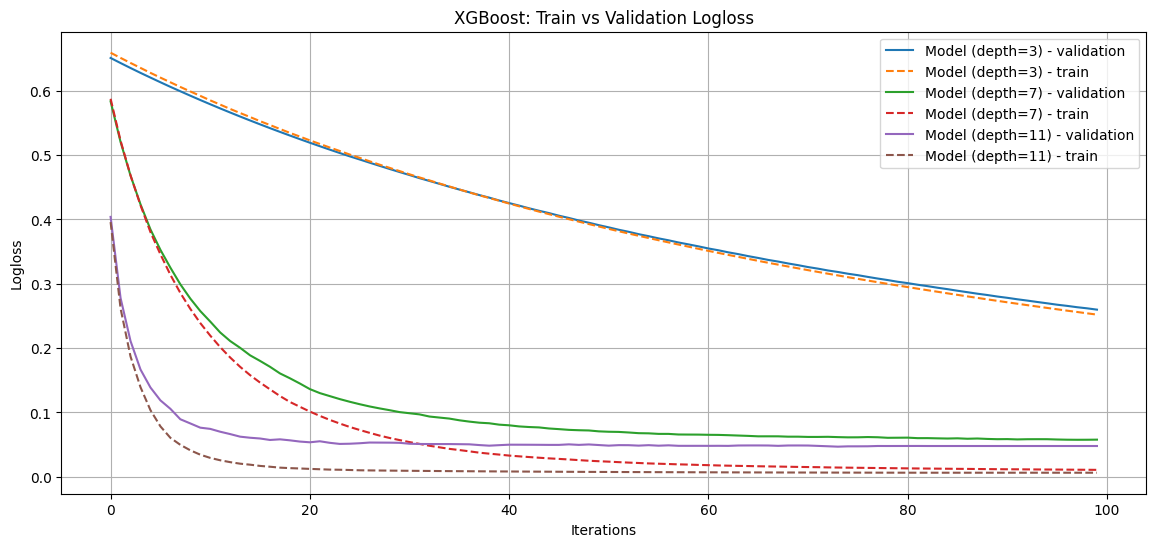

In [83]:
hyperparams_list = [
    {
        'max_depth': 3,
        'learning_rate': 0.01,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (depth=3)'
    },
    {
        'max_depth': 7,
           'learning_rate': 0.1,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (depth=7)'
    },
    {
        'max_depth': 11,
        'learning_rate': 0.4,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (depth=11)'
    }
]

plt.figure(figsize=(14, 6))

for param in hyperparams_list:
    model_name = param.pop('name')

    model = XGBClassifier(
        **param,
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False
    )

    eval_set = [(X_train, y_train_xg), (X_validation, y_validation_xg)]

    model.fit(X_train, y_train_xg, eval_set=eval_set, verbose=False)

    y_pred_model = (model.predict(X_test) > 0.5).astype(int)

    result = model.evals_result()

    keys = list(result.keys())
    train_key = keys[0]
    val_key = keys[1]

    train_loss = result[train_key]['logloss']
    val_loss = result[val_key]['logloss']

    epochs = range(len(train_loss))

    plt.plot(epochs, val_loss, label=f'{model_name} - validation', linestyle='-')
    plt.plot(epochs, train_loss, label=f'{model_name} - train', linestyle='--')

plt.title('XGBoost: Train vs Validation Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for item in f1_score_lr: 
	print(f'Accuracy value with learning rate = {item}')

for item in accuracy_score_lr:
	print(f'F1-score value with learning rare = {item}')

## DEPTH

C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:36:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:36:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\dn156\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:199: UserWarning: [16:36:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


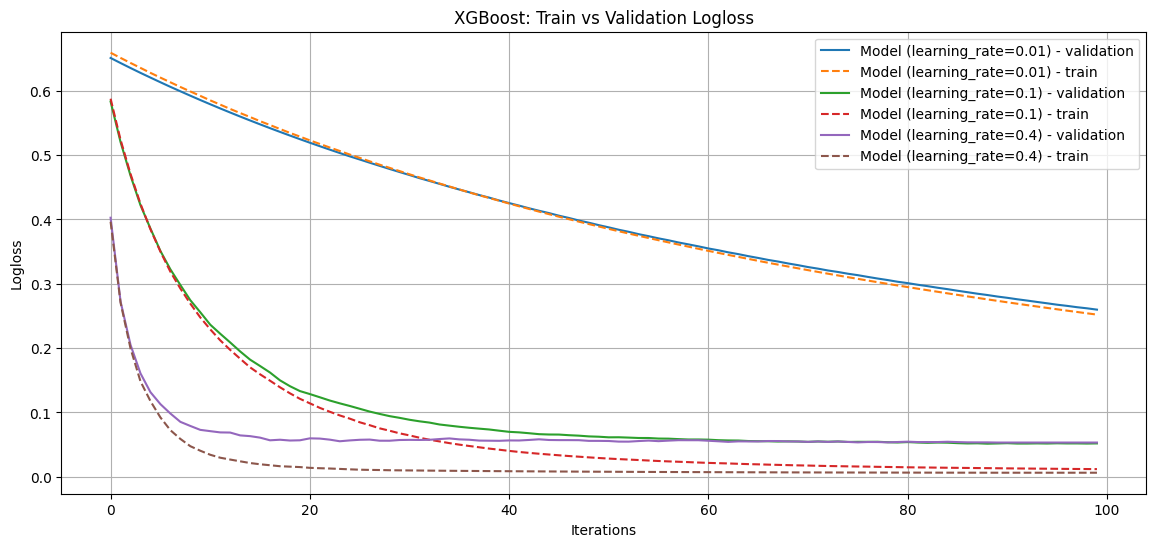

In [85]:
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

hyperparams_list = [
    {
        'max_depth': 3,
        'learning_rate': 0.01,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (learning_rate=0.01)'
    },
    {
        'max_depth': 3,
           'learning_rate': 0.1,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (learning_rate=0.1)'
    },
    {
        'max_depth': 3,
        'learning_rate': 0.4,
        'n_estimators': 100,
        'seed': 0,
        'name': 'Model (learning_rate=0.4)'
    }
]

plt.figure(figsize=(14, 6))

for param in hyperparams_list:
    model_name = param.pop('name')

    model = xgb.XGBClassifier(
        **param,
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False
    )

    eval_set = [(X_train, y_train_xg), (X_validation, y_validation_xg)]

    model.fit(X_train, y_train_xg, eval_set=eval_set, verbose=False)

    y_pred_model = (model.predict(X_test) > 0.5).astype(int)

    result = model.evals_result()

    keys = list(result.keys())
    train_key = keys[0]
    val_key = keys[1]

    train_loss = result[train_key]['logloss']
    val_loss = result[val_key]['logloss']

    epochs = range(len(train_loss))

    plt.plot(epochs, val_loss, label=f'{model_name} - validation', linestyle='-')
    plt.plot(epochs, train_loss, label=f'{model_name} - train', linestyle='--')

plt.title('XGBoost: Train vs Validation Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for item in f1_score_depth: 
	print(f'Accuracy value = {item}')

for item in accuracy_score_depth:
	print(f'F1-score value = {item}')

## Best model

In [86]:
def objective(trial):
    params = {
        "objective": "binary:logistic",
        "use_label_encoder": False,
        "n_estimators": trial.suggest_int("n_estimators", 20, 1000),
        "max_depth": trial.suggest_int("max_depth", 1, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.7),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "enable_categorical": True,
        "eval_metric": "logloss",
        "verbosity": 0,
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        scoring="f1_weighted",
        cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
        n_jobs=-1,
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

best_trial = study.best_trial

print("Best trial:")
print(f"F1 Score: {best_trial.value:.6f}")
print("Parameters:")
for k, v in best_trial.params.items():
    print(f"{k}: {v}")

[I 2025-11-20 16:36:28,752] A new study created in memory with name: no-name-90bf653d-c4ff-4a60-8610-ab174010745d
[I 2025-11-20 16:36:30,983] Trial 0 finished with value: 0.9575798840195493 and parameters: {'n_estimators': 643, 'max_depth': 5, 'learning_rate': 0.14385147830086886, 'gamma': 2.2453585572135883e-06, 'min_child_weight': 4, 'subsample': 0.734603671011116, 'colsample_bytree': 0.6653957681610472, 'reg_alpha': 1.7362718060935498e-08, 'reg_lambda': 0.05928092442466449}. Best is trial 0 with value: 0.9575798840195493.
[I 2025-11-20 16:36:32,461] Trial 1 finished with value: 0.9537757254043978 and parameters: {'n_estimators': 367, 'max_depth': 12, 'learning_rate': 0.11346228978804097, 'gamma': 0.00022004766376159169, 'min_child_weight': 3, 'subsample': 0.9573086641975004, 'colsample_bytree': 0.9259013300348076, 'reg_alpha': 0.007706891462698348, 'reg_lambda': 2.806307956733933e-07}. Best is trial 0 with value: 0.9575798840195493.
[I 2025-11-20 16:36:32,558] Trial 2 finished with 

Best trial:
F1 Score: 0.980594
Parameters:
n_estimators: 926
max_depth: 2
learning_rate: 0.23449315874326226
gamma: 0.156132457976259
min_child_weight: 1
subsample: 0.6667229697321556
colsample_bytree: 0.6652580260423877
reg_alpha: 0.005503003129844526
reg_lambda: 0.5656599173374457
